FULL PIPELINE:
MRI Image
↓
Resize
↓
Normalization
↓
CNN layers
↓
Feature extraction
↓
Dense layer
↓
Sigmoid output
↓
Tumor prediction

In [ ]:
!pip install kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("navoneel/brain-mri-images-for-brain-tumor-detection")

print("Dataset downloaded to:", path)

Using Colab cache for faster access to the 'brain-mri-images-for-brain-tumor-detection' dataset.
Dataset downloaded to: /kaggle/input/brain-mri-images-for-brain-tumor-detection


In [ ]:
import os
os.listdir(path)

['no', 'yes', 'brain_tumor_dataset']

In [ ]:
train = datagen.flow_from_directory(
    path,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary'
)

Found 506 images belonging to 3 classes.


In [ ]:
import os

print(os.listdir(path))

['no', 'yes', 'brain_tumor_dataset']


In [ ]:
dataset_dir = os.path.join(path, "brain_tumor_dataset")

print(os.listdir(dataset_dir))

['no', 'yes']


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [ ]:
train = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 203 images belonging to 2 classes.


In [ ]:
val = datagen.flow_from_directory(
    dataset_dir,
    target_size=(224,224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 50 images belonging to 2 classes.


(np.float64(-0.5), np.float64(223.5), np.float64(223.5), np.float64(-0.5))

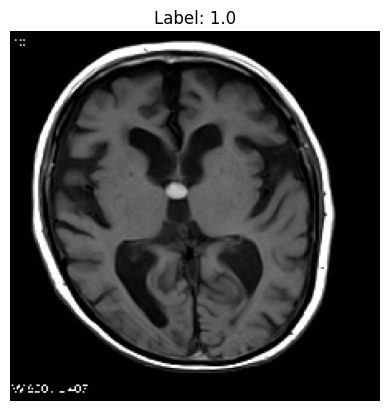

In [ ]:
import matplotlib.pyplot as plt

images, labels = next(train)

plt.imshow(images[0])
plt.title("Label: " + str(labels[0]))
plt.axis("off")

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model = Sequential([

Conv2D(32,(3,3),activation='relu',input_shape=(224,224,3)),
MaxPooling2D(2,2),

Conv2D(64,(3,3),activation='relu'),
MaxPooling2D(2,2),

Conv2D(128,(3,3),activation='relu'),
MaxPooling2D(2,2),

Flatten(),

Dense(128,activation='relu'),

Dense(1,activation='sigmoid')

])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
optimizer='adam',
loss='binary_crossentropy',
metrics=['accuracy']
)

In [ ]:
history = model.fit(
train,
epochs=10,
validation_data=val
)

Epoch 1/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 28s 4s/step - accuracy: 0.6552 - loss: 0.8726 - val_accuracy: 0.7400 - val_loss: 0.5628
Epoch 2/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 24s 3s/step - accuracy: 0.7882 - loss: 0.4937 - val_accuracy: 0.7600 - val_loss: 0.5814
Epoch 3/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 21s 3s/step - accuracy: 0.8325 - loss: 0.4247 - val_accuracy: 0.7400 - val_loss: 0.5786
Epoch 4/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 23s 3s/step - accuracy: 0.8621 - loss: 0.3619 - val_accuracy: 0.7800 - val_loss: 0.5221
Epoch 5/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 20s 3s/step - accuracy: 0.8916 - loss: 0.2736 - val_accuracy: 0.7600 - val_loss: 0.4506
Epoch 6/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9360 - loss: 0.1492 - val_accuracy: 0.8600 - val_loss: 0.4122
Epoch 7/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9655 - loss: 0.1062 - val_accuracy: 0.8600 - val_loss: 0.4663
Epoch 8/10
7/7 ━━━━━━━━━━━━━━━━━━━━ 22s 3s/step - accuracy: 0.9803 - loss: 0.0705 - val_accuracy: 0.8400 - val_loss: 0.5079
Epoch 9/

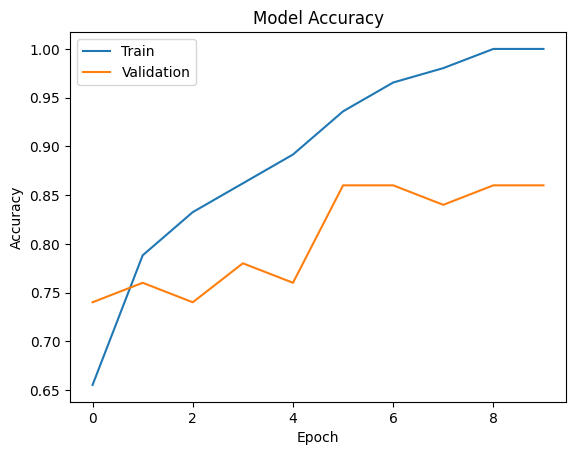

In [ ]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(["Train","Validation"])

plt.show()

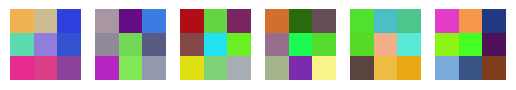

In [ ]:
filters, biases = model.layers[0].get_weights()

f_min, f_max = filters.min(), filters.max()
filters = (filters - f_min) / (f_max - f_min)

for i in range(6):
    plt.subplot(1,6,i+1)
    plt.imshow(filters[:,:,:,i])
    plt.axis('off')

plt.show()

In [ ]:
import cv2
import numpy as np

img = cv2.imread(os.path.join(dataset_dir,"yes","Y1.jpg"))
img = cv2.resize(img,(224,224))
img = img/255

img = np.expand_dims(img,axis=0)

pred = model.predict(img)

print("Tumor probability:",pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 126ms/step
Tumor probability: [[0.9999387]]
